## [Taller 01] Calculo de Raices

### Nonbre: Josue Steven Calvopiña Machuca

### Grupo: 1CC

### Fecha: 12/05/2026

### Introduccion

* Extencion de python: *.py*
* Extencion notebook: *ipynb*

Simbolo de la temrinal:
Bash
```bash
$ cat
```


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import bisect

In [10]:
import pandas as pd


In [28]:
tokens = list(range(1_000_000))
precio = []

# Configuraciones (Precios por token individual)
LIMITE = 272_000
TARIFA_ESTANDAR = 5.00 / 1_000_000  # $5.00 por millón
TARIFA_RECARGO = 10.00 / 1_000_000  # $10.00 por millón (2x)

# Costo acumulado exacto al llegar al límite
COSTO_EN_LIMITE = LIMITE * TARIFA_ESTANDAR

for i in tokens:
    if i <= LIMITE:
        # Tramo 1: Precio normal
        precio.append(i * TARIFA_ESTANDAR)
    else:
        # Tramo 2: El costo base del primer tramo + el excedente con recargo
        excedente = (i - LIMITE) * TARIFA_RECARGO
        precio.append(COSTO_EN_LIMITE + excedente)

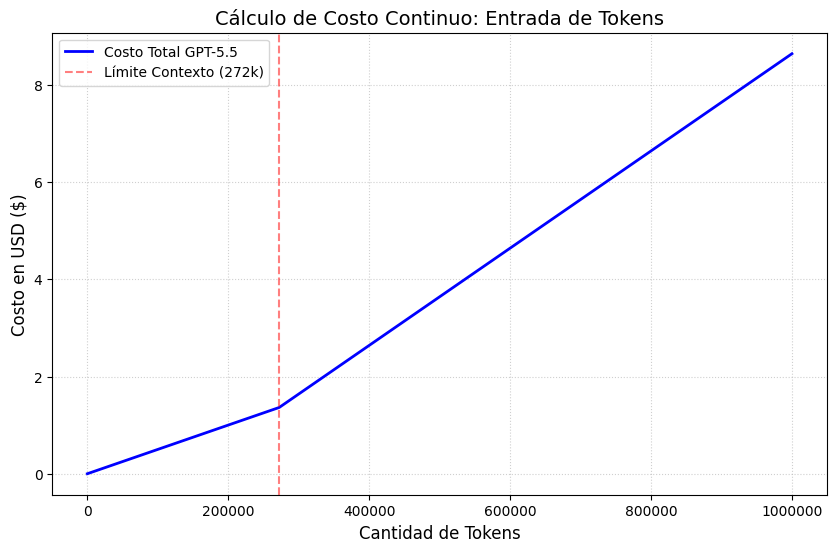

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuración de datos
tokens = np.linspace(0, 1_000_000, 1000)  # De 0 a 1 millón de tokens
limite = 272_000
precio_base = 5.00 / 1_000_000   # Tarifa normal
precio_recargo = 10.00 / 1_000_000  # Tarifa x2
costo_en_limite = limite * precio_base

# 2. Aplicar la lógica de tramos (Continuidad)
# Si el token <= 272k usamos precio_base, si es mayor calculamos el excedente
precio_acumulado = np.where(
    tokens <= limite,
    tokens * precio_base,
    costo_en_limite + (tokens - limite) * precio_recargo
)

# 3. Crear la gráfica
plt.figure(figsize=(10, 6))
plt.plot(tokens, precio_acumulado, label='Costo Total GPT-5.5',
         color='blue', linewidth=2)

# Dibujar la línea del límite para referencia
plt.axvline(x=limite, color='red', linestyle='--',
            alpha=0.5, label='Límite Contexto (272k)')

# 4. Estética y etiquetas
plt.title('Cálculo de Costo Continuo: Entrada de Tokens', fontsize=14)
plt.xlabel('Cantidad de Tokens', fontsize=12)
plt.ylabel('Costo en USD ($)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# Ajustar el formato de los números en los ejes
plt.ticklabel_format(style='plain', axis='x')

# Mostrar la gráfica
plt.show()